# So sánh và Đánh giá các mô hình Anomaly Detection (Expanded Context Window)

Notebook này thực hiện benchmarking các kiến trúc mô hình khác nhau cho bài toán dự báo và phát hiện bất thường trên tập dữ liệu vòng bi đa dạng (Multi-bearing: B01, B02, B03, B04, B05). 

Đặc biệt, phiên bản này được thiết kế và cập nhật dựa trên cấu hình **`configs/***.yaml`** mới nhất với các đặc điểm:
- **Long Context Window**: `lookback = 16384` (gấp 4 lần bản gốc) và `horizon = 1024` để chụp thông tin tần số/chu kỳ dài hơn.
- **Auto-scaled Baselines**: Tự động điều chỉnh kích thước siêu tham số của các mô hình cơ bản (LSTM, PatchLSTM, ModernTCN, VanillaTransformer) để đảm bảo công bằng về mặt tham số so với mô hình **Mamba-Hybrid** (hay **Mamba1-Hybrid**).
- **Huber Loss & Cosine Annealing**: Sử dụng Huber Loss chống nhiễu vibration và bộ lập trình tốc độ học CosineAnnealingLR.
- **Per-bearing Macro Evaluation**: Đánh giá độc lập trên từng vòng bi thử nghiệm để có cái nhìn tổng quan chính xác nhất (tránh lệch nhãn).

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 42.8 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [2]:
import os
import gc
import sys
import time
import yaml
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm
from sklearn.metrics import precision_recall_curve, auc as auc_score_func
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Tự động phát hiện môi trường chạy (Kaggle hay Local)
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

if is_kaggle:
    # 1. Thêm đường dẫn mã nguồn trên Kaggle vào sys.path
    kaggle_source_root = '/kaggle/input/mamba-sft-source'
    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root
    print(f'Added Kaggle source path to sys.path: {kaggle_source_root}')
else:
    # Môi trường Local
    project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
    if project_root not in sys.path:
        sys.path.append(project_root)
    print(f'Running locally. Project root: {project_root}')
    
from src.data import BearingDataset, MultiBearingDataset
from src.models.baselines.lstm import LSTMForecaster
from src.models.baselines.tcn import TCNForecaster
from src.models.baselines.modern_tcn import ModernTCNForecaster
from src.models.baselines.patch_models import VanillaTransformer
from src.models.baselines.patch_models import PatchLSTM
from src.models.mamba import HybridMambaCNN
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma, 
    calculate_threshold_robust, 
    calculate_threshold_percentile, 
    calculate_threshold_gmm, 
    find_best_threshold, 
    calculate_metrics, 
    calculate_threshold_pot
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Is running on Kaggle: True
Added Kaggle source path to sys.path: /kaggle/input/mamba-sft-source
Using device: cuda


## 1. Đọc và tải Cấu hình từ configs/***.yaml

In [3]:
config_path = os.path.join(project_root, 'configs/nano.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Cập nhật đường dẫn tương đối cho phù hợp với vị trí chạy từ notebooks
config['data']['train_datasets'] = [os.path.join(project_root, d) for d in config['data']['train_datasets']]
config['data']['test_datasets'] = [os.path.join(project_root, d) for d in config['data']['test_datasets']]

print("--- Loaded Configuration ---")
for k, v in config.items():
    print(f"{k}: {v}")

--- Loaded Configuration ---
data: {'raw_dir': 'data/raw/B04', 'processed_dir': 'data/processed/B04', 'train_datasets': ['/kaggle/input/mamba-sft-source/data/processed/B02', '/kaggle/input/mamba-sft-source/data/processed/B05'], 'test_datasets': ['/kaggle/input/mamba-sft-source/data/processed/B02', '/kaggle/input/mamba-sft-source/data/processed/B03', '/kaggle/input/mamba-sft-source/data/processed/B04', '/kaggle/input/mamba-sft-source/data/processed/B05'], 'sampling_rate': 128000, 'highpass_freq': 2000, 'label_strategy': 'rms', 'window_stride': 1024, 'lookback': 4096, 'horizon': 1024, 'skip_ratio': 0.05, 'train_ratio': 0.4}
model: {'patch_size': 64, 'patch_stride': 32, 'trend_downsample': 64, 'cnn_out_channels': 64, 'mamba_d_model': 64, 'mamba_n_layer': 4, 'mamba_d_state': 16, 'mamba_d_conv': 3, 'mamba_expand': 3, 'bidirectional': False, 'decomp_kernel': 25, 'auto_scale_baselines': True}
training: {'batch_size': 128, 'learning_rate': '5e-4', 'epochs': 10, 'device': 'cuda'}
logging: {'pro

## 2. Các hàm hỗ trợ Auto-Scaling siêu tham số (Khớp tham số của Mamba)

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def find_closest_lstm(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for h in range(8, 1024, 2):
        model = LSTMForecaster(input_dim=2, hidden_dim=h, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = h
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_patch_lstm(target, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = PatchLSTM(in_channels=2, patch_size=patch_size, stride=stride, d_model=d, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_modern_tcn(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = ModernTCNForecaster(input_dim=2, d_model=d, num_layers=3, kernel_size=17, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_vanilla_transformer(target, lookback, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 4):
        nhead = 4 if d >= 4 else 1
        if d % 4 != 0:
            nhead = 2 if d % 2 == 0 else 1
        model = VanillaTransformer(in_channels=2, lookback=lookback, patch_size=patch_size, stride=stride, d_model=d, nhead=nhead, num_layers=4, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


def find_closest_simple_mamba(target, lookback, patch_size, stride, horizon, mamba_n_layer=4, mamba_d_state=16, mamba_d_conv=4, mamba_expand=2, mamba_version=1):
    from src.models.mamba import SimpleMamba
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = SimpleMamba({
            'model': {
                'mamba_version': mamba_version,
                'mamba_d_model': d,
                'mamba_n_layer': mamba_n_layer,
                'mamba_d_state': mamba_d_state,
                'mamba_d_conv': mamba_d_conv,
                'mamba_expand': mamba_expand,
                'forecast_len': horizon,
                'patch_size': patch_size,
                'stride': stride,
                'in_channels': 2,
                'lookback': lookback,
            },
            'data': {'patch_size': patch_size, 'stride': stride, 'lookback': lookback}
        })
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


## 3. Định nghĩa Early Stopping

In [5]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## 4. Tải các tập dữ liệu vòng bi (MultiBearingDataset)

In [6]:
window_stride = config['data'].get('window_stride', 2048)
lookback = config['data'].get('lookback', 16384)
horizon = config['data'].get('horizon', 1024)
sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = config['data'].get('highpass_freq', 2000)
train_ratio = config['data'].get('train_ratio', 0.5)
skip_ratio = config['data'].get('skip_ratio', 0.1)
# batch_size = config['training'].get('batch_size', 8)
batch_size = 32

# train_dirs = config['data']['train_datasets']
# test_dirs = config['data']['test_datasets']
train_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B02", 
              "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
test_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B02",
            "/kaggle/input/datasets/sunbv21/dataset-bearings/B03",
            "/kaggle/input/datasets/sunbv21/dataset-bearings/B04",
            "/kaggle/input/datasets/sunbv21/dataset-bearings/B05",]

print('Loading train datasets...')
train_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='train',
    file_sample_ratio=1, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate
)

oc_stats = train_dataset.oc_stats

print('Loading val datasets...')
val_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate
)

print('Loading test datasets...')
test_dataset = MultiBearingDataset(
    test_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='test',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('\n--- Dữ liệu tải thành công ---')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Loading train datasets...
Loading val datasets...
Loading test datasets...

--- Dữ liệu tải thành công ---
Train samples: 66444
Val samples: 33124
Test samples: 669536


## 5. Khởi tạo Mô hình và Tự động điều chỉnh kích thước siêu tham số (Auto-scaling)

In [7]:
patch_size = config['model'].get('patch_size', 128)
patch_stride = config['model'].get('patch_stride', 64)
trend_downsample = config['model'].get('trend_downsample', 16)
decomp_kernel = config['model'].get('decomp_kernel', 49)

mamba_model = HybridMambaCNN({
    'model': {
        'mamba_version': 1,
        'mamba_d_model': config['model'].get('mamba_d_model', 16),
        'mamba_n_layer': config['model'].get('mamba_n_layer', 1),
        'mamba_d_state': config['model'].get('mamba_d_state', 8),
        'mamba_d_conv': config['model'].get('mamba_d_conv', 4),
        'mamba_expand': config['model'].get('mamba_expand', 2),
        'forecast_len': horizon,
        'patch_size': patch_size,
        'stride': patch_stride,
        'trend_downsample': trend_downsample,
        'in_channels': 2, 'lookback': lookback,
        'decomp_kernel': decomp_kernel,
        'use_multiscale': config.get('model', {}).get('use_multiscale', True),
        'use_revin': config.get('model', {}).get('use_revin', True),
        'use_decomposition': config.get('model', {}).get('use_decomposition', True),
        'use_stats': config.get('model', {}).get('use_stats', True),
    },
    'data': {
        'patch_size': patch_size,
        'stride': patch_stride,
        'lookback': lookback
    }
})

mamba_params = count_parameters(mamba_model)
auto_scale = config.get('model', {}).get('auto_scale_baselines', True)

if auto_scale:
    print(f'[AUTO-SCALE] Đang điều chỉnh baselines khớp Ngân sách Tham số Mamba (~{mamba_params:,} params)...\n')
    lstm_dim, lstm_p = find_closest_lstm(mamba_params, horizon)
    pl_dim, pl_p = find_closest_patch_lstm(mamba_params, patch_size, patch_stride, horizon)
    tcn_dim, tcn_p = find_closest_modern_tcn(mamba_params, horizon)
    pt_dim, pt_p = find_closest_vanilla_transformer(mamba_params, lookback, patch_size, patch_stride, horizon)
    
    print(f'  -> LSTM: hidden_dim={lstm_dim} ({lstm_p:,} params)')
    print(f'  -> PatchLSTM: d_model={pl_dim} ({pl_p:,} params)')
    print(f'  -> ModernTCN: d_model={tcn_dim} ({tcn_p:,} params)')
    print(f'  -> VanillaTransformer: d_model={pt_dim} ({pt_p:,} params)')
    
    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=lstm_dim, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=patch_size, stride=patch_stride, d_model=pl_dim, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=tcn_dim, num_layers=3, kernel_size=17, horizon=horizon)
    
    nhead = 4 if pt_dim >= 4 else 1
    if pt_dim % 4 != 0:
        nhead = 2 if pt_dim % 2 == 0 else 1
    vanilla_transformer = VanillaTransformer(in_channels=2, lookback=lookback, patch_size=patch_size, stride=patch_stride, d_model=pt_dim, nhead=nhead, num_layers=3, horizon=horizon)
else:
    print('[AUTO-SCALE] Sử dụng cấu hình mặc định...')
    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=140, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=64, stride=64, d_model=120, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=160, num_layers=3, kernel_size=17, horizon=horizon)
    vanilla_transformer = VanillaTransformer(in_channels=2, lookback=lookback, patch_size=64, stride=64, d_model=64, nhead=4, num_layers=3, horizon=horizon)

models = {
    # 'LSTM': lstm_forecaster,
    # 'PatchLSTM': patch_lstm,
    # 'ModernTCN': modern_tcn,
    # 'VanillaTransformer': vanilla_transformer,
    'Mamba-Hybrid': mamba_model
}

for name, model in models.items():
    n_params = count_parameters(model)
    print(f'{name}: {n_params:,} parameters')
    model.to(device)
    # if torch.cuda.device_count() > 1:
    #     print(f'   => Sử dụng {torch.cuda.device_count()} GPUs cho {name}')
    #     models[name] = nn.DataParallel(model)

[AUTO-SCALE] Đang điều chỉnh baselines khớp Ngân sách Tham số Mamba (~339,922 params)...

  -> LSTM: hidden_dim=88 (340,144 params)
  -> PatchLSTM: d_model=82 (341,528 params)
  -> ModernTCN: d_model=102 (344,156 params)
  -> VanillaTransformer: d_model=84 (349,792 params)
VanillaTransformer: 349,792 parameters
Mamba-Hybrid: 339,922 parameters


## 6. Định nghĩa Hàm Huấn luyện và Đánh giá nâng cao (Huber Loss, Cosine Annealing, Per-bearing)

In [8]:
def train_one_model_in_notebook(name, model, train_loader, val_loader, test_loader, config, device, config_name='nano'):
    print(f'\n>>> Huấn luyện {name} (Cấu hình: {config_name})...')
    model.to(device)
    
    lr = float(config['training'].get('learning_rate', 5e-4))
    # epochs = int(config['training'].get('epochs', 10))
    epochs = 10
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-2)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    save_dir = '/kaggle/working/models'
    os.makedirs(save_dir, exist_ok=True)
    
    model_slug = name.lower().replace('-', '_')
    best_model_path = os.path.join(save_dir, f'{model_slug}_{config_name}_best.pth')
    early_stopping = EarlyStopping(patience=3, verbose=True, path=best_model_path)
    
    losses = []
    start_train = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'{name} - Epoch {epoch}/{epochs}')
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                if stats is not None and isinstance(model, HybridMambaCNN):
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)
            
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch}/{epochs}] - Train Loss: {avg_loss:.6f}')
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch [{epoch}/{epochs}] - Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e}')
        
        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print('Early stopping kích hoạt!')
            break
            
    train_duration = time.time() - start_train
    print(f'Huấn luyện tốn {train_duration:.2f} giây')

    # Tải lại trọng số tốt nhất
    print(f'Loading best model weights from {best_model_path}...')
    model.load_state_dict(torch.load(best_model_path, weights_only=True))

    # Tính ngưỡng toàn cục (Global Threshold) từ tập Train
    print('Tính ngưỡng trên tập Train...')
    train_scores_sample = []
    model.eval()
    with torch.no_grad():
        for batch in train_loader:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            if stats is not None and isinstance(model, HybridMambaCNN):
                y_pred = model(x, stats)
            else:
                y_pred = model(x)
            scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)
            train_scores_sample.extend(scores.tolist())

    train_scores_sample = np.array(train_scores_sample)
    threshold_3s  = calculate_threshold_3sigma(train_scores_sample)
    threshold_rb  = calculate_threshold_robust(train_scores_sample)
    threshold_pc  = calculate_threshold_percentile(train_scores_sample, q=99.7)
    threshold_pot = calculate_threshold_pot(train_scores_sample, q=1e-3)

    # Đánh giá độc lập trên từng Vòng bi Thử nghiệm (Per-bearing evaluation)
    print('\n>>> ĐÁNH GIÁ TRÊN TẬP TEST (Độc lập từng Vòng Bi)...')
    macro_metrics = {
        '3-Sigma': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []},
        'Robust': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []},
        'Percentile': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []},
        'POT': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []},
        'Self-Learn': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []},
        'Optimal': {'F1': [], 'FAR': [], 'AUC': [], 'AUPRC': []}
    }
    
    total_test_latencies = []
    skip_ratio = config['data'].get('skip_ratio', 0.1)
    train_ratio = config['data'].get('train_ratio', 0.5)

    test_datasets = test_loader.dataset.datasets if hasattr(test_loader.dataset, 'datasets') else [test_loader.dataset]

    model.eval()
    last_bearing_scores = None
    last_bearing_labels = None
    last_bearing_th = None
    
    for test_idx, ds in enumerate(test_datasets):
        bearing_name = os.path.basename(ds.data_dir) if hasattr(ds, 'data_dir') else f'Dataset_{test_idx}'
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        bearing_scores = []
        bearing_labels = []
        
        with torch.no_grad():
            for batch in loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None

                start_inf = time.time()
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                
                total_test_latencies.append((time.time() - start_inf) / x.size(0))
                scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)
                bearing_scores.extend(scores.tolist())

                if len(batch) > 3:
                    labels_batch = batch[3]
                    if hasattr(labels_batch, 'numpy'):
                        bearing_labels.extend(labels_batch.numpy().tolist())
                    else:
                        bearing_labels.extend([int(l) for l in labels_batch])
                else:
                    bearing_labels.extend([0] * x.size(0))

        bearing_scores = np.array(bearing_scores)
        bearing_labels = np.array(bearing_labels, dtype=int)
        
        n_fault = int(bearing_labels.sum())
        n_total = len(bearing_labels)
        print(f'\n  [{bearing_name}] Phân bố nhãn: {n_fault}/{n_total} windows lỗi ({n_fault/n_total:.1%})')

        # Tính toán Local Thresholds
        skip_end = int(n_total * skip_ratio)
        train_end = int(n_total * (skip_ratio + train_ratio))
        
        normal_indices = np.where(bearing_labels == 0)[0]
        if len(normal_indices) > 0:
            train_end = min(train_end, normal_indices[-1] + 1)
            
        if train_end > skip_end:
            healthy_subset = bearing_scores[skip_end:train_end]
            healthy_labels = bearing_labels[skip_end:train_end]
            healthy_scores = healthy_subset[healthy_labels == 0]
            if len(healthy_scores) == 0:
                healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
        else:
            healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
            
        local_th_3s  = calculate_threshold_3sigma(healthy_scores)
        local_th_rb  = calculate_threshold_robust(healthy_scores)
        local_th_pc  = calculate_threshold_percentile(healthy_scores, q=99.7)
        local_th_pot = calculate_threshold_pot(healthy_scores, q=1e-3)
        local_th_gmm = calculate_threshold_gmm(bearing_scores)
        local_th_opt, _ = find_best_threshold(bearing_scores, bearing_labels)

        # Lưu trữ lại kết quả của vòng bi cuối phục vụ vẽ đồ thị
        last_bearing_scores = bearing_scores
        last_bearing_labels = bearing_labels
        last_bearing_th = local_th_rb

        if len(np.unique(bearing_labels)) > 1:
            precision_path, recall_path, _ = precision_recall_curve(bearing_labels, bearing_scores)
            bearing_auprc = auc_score_func(recall_path, precision_path)
        else:
            bearing_auprc = 0.0

        thresholds = [
            ('3-Sigma', local_th_3s), ('Robust', local_th_rb), ('Percentile', local_th_pc),
            ('POT', local_th_pot), ('Self-Learn', local_th_gmm), ('Optimal', local_th_opt)
        ]
        
        for t_name, t_val in thresholds:
            m = calculate_metrics(bearing_scores, bearing_labels, t_val)
            macro_metrics[t_name]['F1'].append(m.get('F1', 0))
            macro_metrics[t_name]['FAR'].append(m.get('FAR', 0))
            macro_metrics[t_name]['AUC'].append(m.get('AUC', 0))
            macro_metrics[t_name]['AUPRC'].append(bearing_auprc)
            
            if t_name in ['Robust', 'POT', 'Optimal']:
                print(f'     - {t_name:<7}: F1={m.get("F1",0):.4f} | FAR={m.get("FAR",0):.4f} | Thresh={t_val:.4f}')

    test_latency_avg = np.mean(total_test_latencies) * 1000

    print('\n============================================================')
    print(f'>>> MACRO-AVERAGE PERFORMANCE ({len(test_datasets)} Bearings)')
    for t_name in macro_metrics.keys():
        avg_f1 = np.mean(macro_metrics[t_name]['F1'])
        avg_far = np.mean(macro_metrics[t_name]['FAR'])
        avg_auc = np.mean(macro_metrics[t_name]['AUC'])
        avg_auprc = np.mean(macro_metrics[t_name]['AUPRC'])
        print(f'   [{t_name:<10}] > F1: {avg_f1:.4f} | FAR: {avg_far:.4f} | AUC: {avg_auc:.4f} | AUPRC: {avg_auprc:.4f}')
    print(f'   > Độ trễ trung bình: {test_latency_avg:.4f} ms/sample')
    print('============================================================')

    res = {
        'name': name,
        'losses': losses,
        'f1': float(np.mean(macro_metrics['Robust']['F1'])),
        'f1_3s': float(np.mean(macro_metrics['3-Sigma']['F1'])),
        'f1_rb': float(np.mean(macro_metrics['Robust']['F1'])),
        'f1_pot': float(np.mean(macro_metrics['POT']['F1'])),
        'f1_gmm': float(np.mean(macro_metrics['Self-Learn']['F1'])),
        'f1_opt': float(np.mean(macro_metrics['Optimal']['F1'])),
        'auc': float(np.mean(macro_metrics['Robust']['AUC'])),
        'far': float(np.mean(macro_metrics['Robust']['FAR'])),
        'auprc': float(np.mean(macro_metrics['Robust']['AUPRC'])),
        'latency': float(test_latency_avg),
        'last_scores': last_bearing_scores,
        'last_labels': last_bearing_labels,
        'threshold': last_bearing_th,
        'train_duration': float(train_duration)
    }

    # Dọn dẹp GPU cache
    del model
    optimizer.zero_grad(set_to_none=True)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    return res

## 7. Tiến hành Huấn luyện tất cả các mô hình

In [9]:
results = {}

for name, model in models.items():
    res = train_one_model_in_notebook(name, model, train_loader, val_loader, test_loader, config, device, config_name='nano')
    results[name] = res


>>> Huấn luyện VanillaTransformer (Cấu hình: nano)...


VanillaTransformer - Epoch 1/10:   0%|          | 0/2077 [00:00<?, ?it/s]

Epoch [1/10] - Train Loss: 0.147558
Epoch [1/10] - Val Loss: 0.143279 | LR: 5.00e-04
Validation loss decreased (inf --> 0.143279).  Saving model ...


VanillaTransformer - Epoch 2/10:   0%|          | 0/2077 [00:00<?, ?it/s]

Epoch [2/10] - Train Loss: 0.143361
Epoch [2/10] - Val Loss: 0.142291 | LR: 4.88e-04
Validation loss decreased (0.143279 --> 0.142291).  Saving model ...


...

Epoch [8/10] - Train Loss: 0.143745
Epoch [8/10] - Val Loss: 0.143488 | LR: 1.07e-04
Validation loss decreased (0.144163 --> 0.143488).  Saving model ...


Mamba-Hybrid - Epoch 9/10:   0%|          | 0/2077 [00:00<?, ?it/s]

Epoch [9/10] - Train Loss: 0.143301
Epoch [9/10] - Val Loss: 0.143301 | LR: 5.23e-05
Validation loss decreased (0.143488 --> 0.143301).  Saving model ...


Mamba-Hybrid - Epoch 10/10:   0%|          | 0/2077 [00:00<?, ?it/s]

Epoch [10/10] - Train Loss: 0.143068
Epoch [10/10] - Val Loss: 0.143179 | LR: 1.71e-05
Validation loss decreased (0.143301 --> 0.143179).  Saving model ...
Huấn luyện tốn 1190.30 giây
Loading best model weights from /kaggle/working/models/mamba_hybrid_nano_best.pth...
Tính ngưỡng trên tập Train...

>>> ĐÁNH GIÁ TRÊN TẬP TEST (Độc lập từng Vòng Bi)...

  [B02] Phân bố nhãn: 48020/218736 windows lỗi (22.0%)
     - Robust : F1=0.9811 | FAR=0.0108 | Thresh=0.8156
     - POT    : F1=0.9868 | FAR=0.0075 | Thresh=0.9131
     - Optimal: F1=0.9947 | FAR=0.0018 | Thresh=2.0287

  [B03] Phân bố nhãn: 11172/120344 windows lỗi (9.3%)
     - Robust : F1=0.9483 | FAR=0.0111 | Thresh=0.7444
     - POT    : F1=0.9609 | FAR=0.0083 | Thresh=0.8129
     - Optimal: F1=0.9788 | FAR=0.0031 | Thresh=2.2996

  [B04] Phân bố nhãn: 131516/218344 windows lỗi (60.2%)
     - Robust : F1=0.9835 | FAR=0.0038 | Thresh=0.6799
     - POT    : F1=0.9780 | FAR=0.0015 | Thresh=0.7617
     - Optimal: F1=0.9819 | FAR=0.0028 

## 8. Trực quan hóa và So sánh Kết quả (Bar Charts & Anomaly Scores Flow)

/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 7881 (\N{LATIN SMALL LETTER I WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 7907 (\N{LATIN SMALL LETTER O WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094.py:58: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/75123094

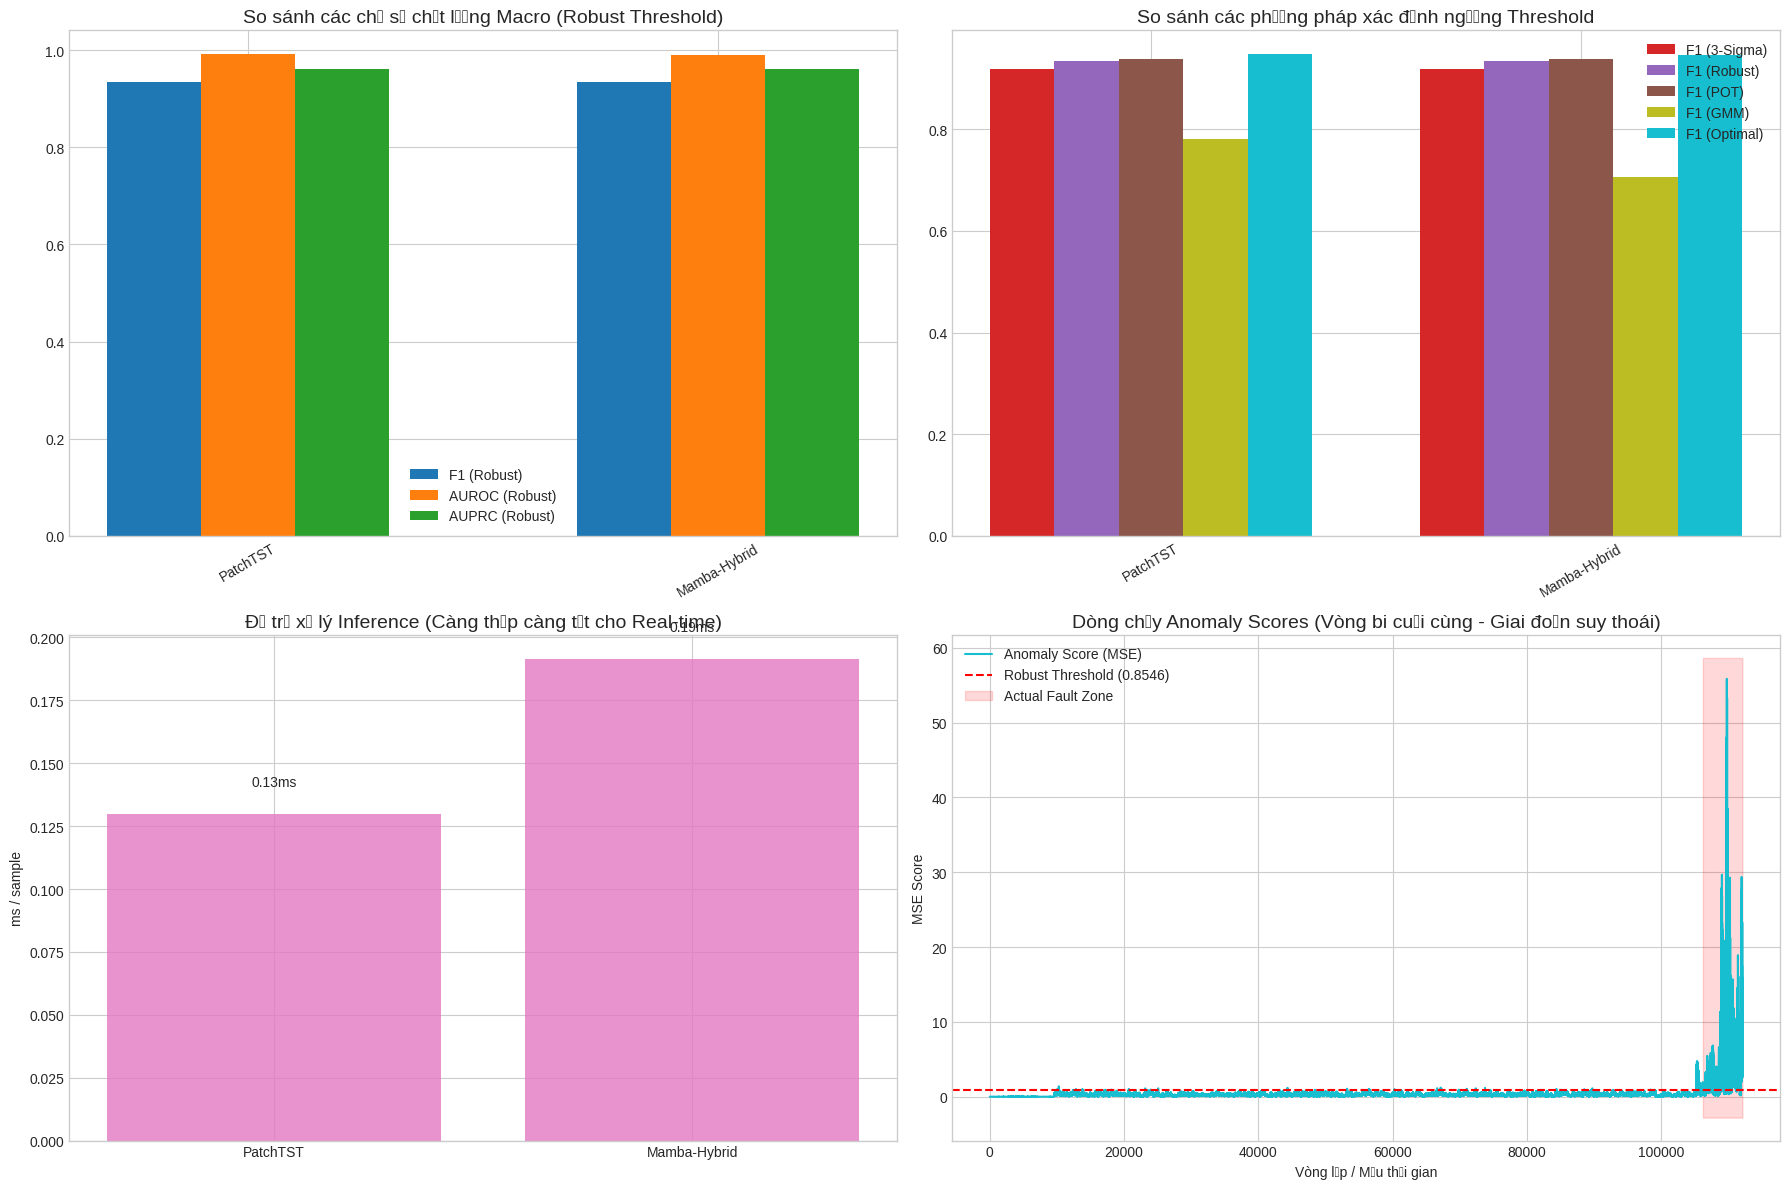

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

names = list(results.keys())
x = np.arange(len(names))

# --- 8.1 So sánh F1, AUC và AUPRC (Macro) ---
ax1 = plt.subplot(2, 2, 1)
width = 0.2
ax1.bar(x - width, [results[n]['f1_rb'] for n in names], width, label='F1 (Robust)', color='#1f77b4')
ax1.bar(x, [results[n]['auc'] for n in names], width, label='AUROC (Robust)', color='#ff7f0e')
ax1.bar(x + width, [results[n]['auprc'] for n in names], width, label='AUPRC (Robust)', color='#2ca02c')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30)
ax1.set_title('So sánh các chỉ số chất lượng Macro (Robust Threshold)', fontsize=14)
ax1.legend()

# --- 8.2 So sánh F1 giữa các phương pháp xác định ngưỡng ---
ax2 = plt.subplot(2, 2, 2)
ax2.bar(x - 0.3, [results[n]['f1_3s'] for n in names], 0.15, label='F1 (3-Sigma)', color='#d62728')
ax2.bar(x - 0.15, [results[n]['f1_rb'] for n in names], 0.15, label='F1 (Robust)', color='#9467bd')
ax2.bar(x, [results[n]['f1_pot'] for n in names], 0.15, label='F1 (POT)', color='#8c564b')
ax2.bar(x + 0.15, [results[n]['f1_gmm'] for n in names], 0.15, label='F1 (GMM)', color='#bcbd22')
ax2.bar(x + 0.3, [results[n]['f1_opt'] for n in names], 0.15, label='F1 (Optimal)', color='#17becf')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30)
ax2.set_title('So sánh các phương pháp xác định ngưỡng Threshold', fontsize=14)
ax2.legend()

# --- 8.3 So sánh Độ trễ (Latency) ---
ax3 = plt.subplot(2, 2, 3)
latencies = [results[n]['latency'] for n in names]
bars = ax3.bar(names, latencies, color='#e377c2', alpha=0.8)
ax3.set_ylabel('ms / sample')
ax3.set_title('Độ trễ xử lý Inference (Càng thấp càng tốt cho Real-time)', fontsize=14)
for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}ms', ha='center', va='bottom')

# --- 8.4 Biểu đồ Anomaly Scores của mô hình Mamba-Hybrid trên Bearing cuối cùng ---
ax4 = plt.subplot(2, 2, 4)
if 'Mamba-Hybrid' in results:
    mamba_res = results['Mamba-Hybrid']
    ax4.plot(mamba_res['last_scores'], label='Anomaly Score (MSE)', color='#17becf')
    ax4.axhline(y=mamba_res['threshold'], color='red', linestyle='--', label=f'Robust Threshold ({mamba_res["threshold"]:.4f})')
    
    # Tô màu vùng lỗi thực tế nếu có nhãn
    labels = mamba_res['last_labels']
    if labels is not None and len(labels) > 0:
        ax4.fill_between(range(len(labels)), ax4.get_ylim()[0], ax4.get_ylim()[1], 
                         where=(labels == 1), color='red', alpha=0.15, label='Actual Fault Zone')
                         
    ax4.set_title('Dòng chảy Anomaly Scores (Vòng bi cuối cùng - Giai đoạn suy thoái)', fontsize=14)
    ax4.set_xlabel('Vòng lặp / Mẫu thời gian')
    ax4.set_ylabel('MSE Score')
    ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 9. Trực quan hóa Nâng cao (Heatmap thời gian & Phân bổ Violin)

/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7851 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND TILDE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7917 (\N{LATIN SMALL LETTER U WITH HORN AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7901 (\N{LATIN SMALL LETTER O WITH HORN AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2593697661.py:49: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  

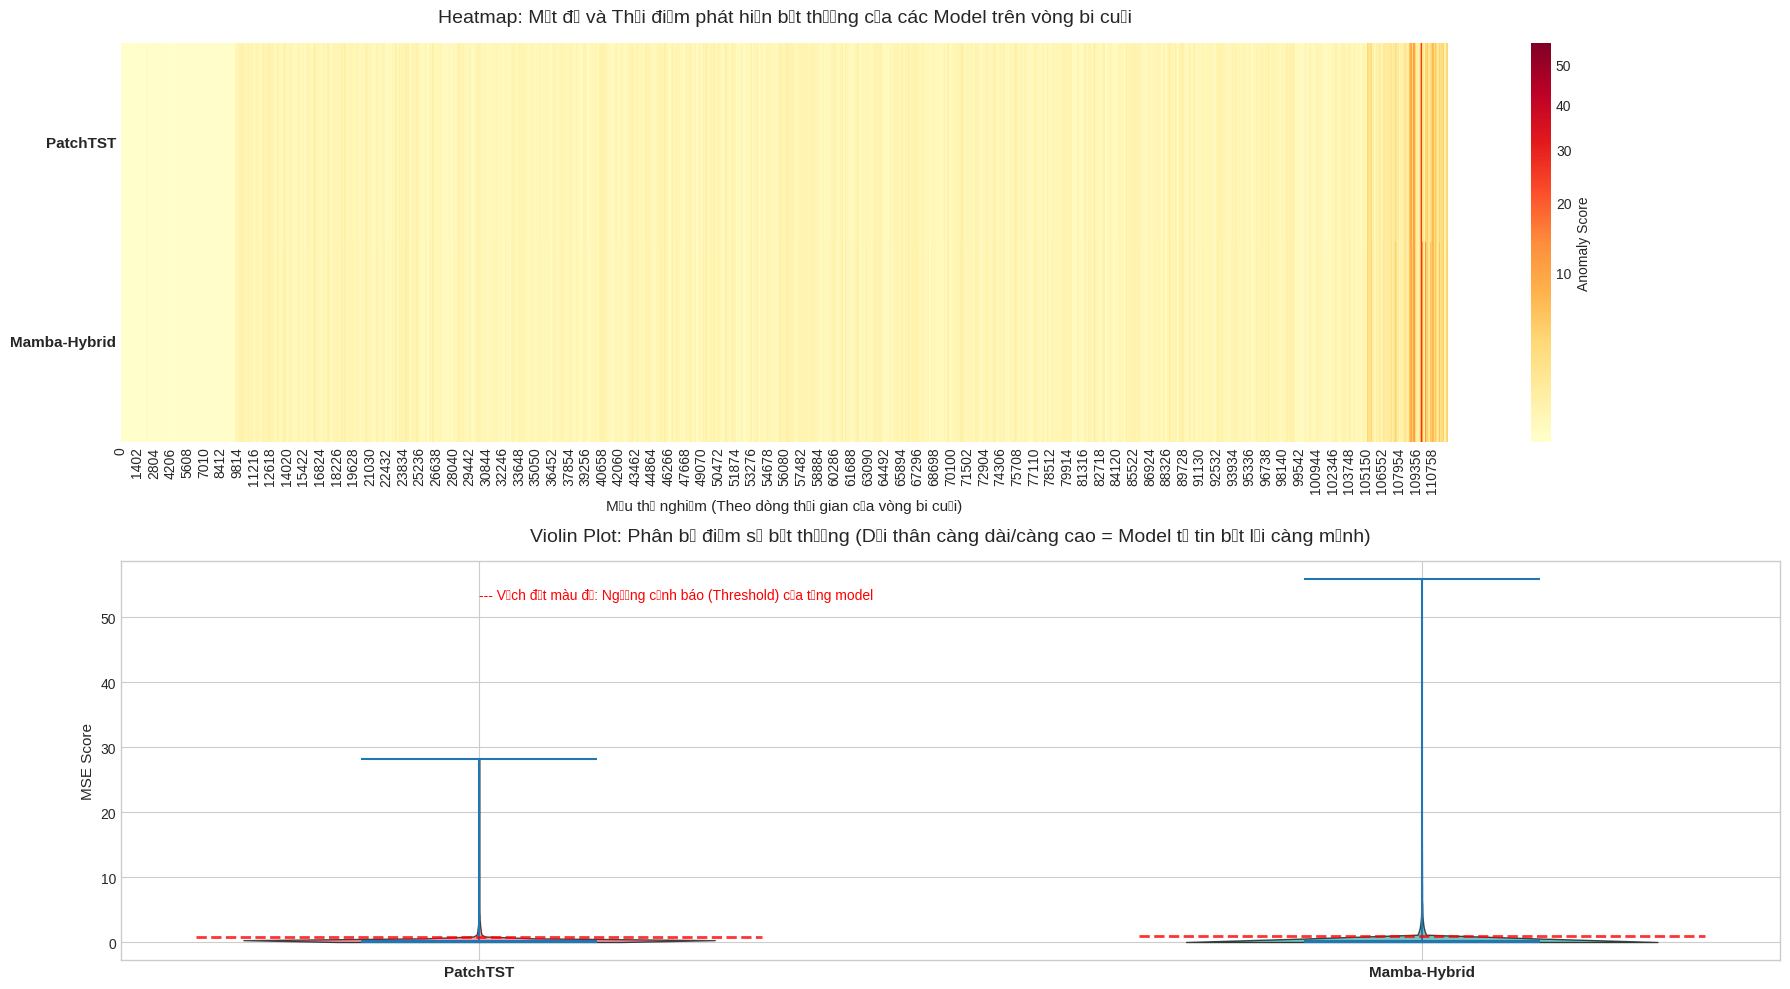

In [11]:
fig = plt.figure(figsize=(18, 10))

scores_matrix = []
valid_names = []
for name in names:
    if results[name]['last_scores'] is not None:
        scores_matrix.append(results[name]['last_scores'])
        valid_names.append(name)
        
scores_matrix = np.array(scores_matrix)

# ==========================================
# 1. HEATMAP: Trực quan hóa theo thời gian
# ==========================================
ax1 = plt.subplot(2, 1, 1)
import matplotlib.colors as mcolors
norm = mcolors.PowerNorm(gamma=0.5)

sns.heatmap(scores_matrix, cmap='YlOrRd', ax=ax1, norm=norm, cbar_kws={'label': 'Anomaly Score'})
ax1.set_yticks(np.arange(len(valid_names)) + 0.5)
ax1.set_yticklabels(valid_names, rotation=0, fontsize=11, fontweight='bold')
ax1.set_xlabel('Mẫu thử nghiệm (Theo dòng thời gian của vòng bi cuối)', fontsize=11)
ax1.set_title('Heatmap: Mật độ và Thời điểm phát hiện bất thường của các Model trên vòng bi cuối', fontsize=14, pad=15)

# ==========================================
# 2. VIOLIN PLOT: So sánh sự phân bố điểm số
# ==========================================
ax2 = plt.subplot(2, 1, 2)
data_to_plot = [results[name]['last_scores'] for name in valid_names]

parts = ax2.violinplot(data_to_plot, showmeans=False, showmedians=True, showextrema=True)

colors = sns.color_palette('husl', len(valid_names))
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

ax2.set_xticks(np.arange(1, len(valid_names) + 1))
ax2.set_xticklabels(valid_names, fontsize=11, fontweight='bold')
ax2.set_ylabel('MSE Score', fontsize=11)
ax2.set_title('Violin Plot: Phân bố điểm số bất thường (Dải thân càng dài/càng cao = Model tự tin bắt lỗi càng mạnh)', fontsize=14, pad=15)

for i, name in enumerate(valid_names):
    ax2.hlines(results[name]['threshold'], i+0.7, i+1.3, color='red', linestyle='--', alpha=0.8, linewidth=2)
    
ax2.text(1, ax2.get_ylim()[1]*0.9, '--- Vạch đứt màu đỏ: Ngưỡng cảnh báo (Threshold) của từng model', color='red', fontsize=10)

plt.tight_layout()
plt.show()